# Final Project Notebook

Use the following cells prompts to complete the final project for the course. Everything you need should be present in this notebook or previous notebooks we've used in class. You can work together as needed. 

 - You will need to name your own dataset and use that name throughout
 - There are sections where you need to make changes the code and insert new code this will be noted in the code provided
 - You may get frustrated along the way, this is totally normal, just remember even small changes to the code make a huge difference.


## Question Fork the Repository
i. Include a screenshot of the forked repo in your GitHub account

To fork the repository:
1. Go to https://github.com/NovaVolunteer/ds1001_final
2. Click the "Fork" button in the top right corner
3. The repo will be forked to your GitHub account
4. Take a screenshot of your forked repository


### You should now be able to open your cloned repo in GitHub Codespaces.

### It's very helpful to have the variable inspector open while you go through this process.

### It's also helpful to open up the folder tree on the left menu bar. Just click on the folder icon and then the ds1001_final folder. The data is located in the data folder in the processed sub-folder.


## Systems


Since we are working in GitHub Codespaces, we do not need to clone the repo — it is already available in our workspace. We skip the git clone cell and begin from the environment setup.


In [1]:
# Activate the finalproj environment
!source ds1001_final/finalproj/bin/activate


/bin/bash: line 1: ds1001_final/finalproj/bin/activate: No such file or directory


In [2]:
### List all the packages in your environment
!pip list


Package                   Version
------------------------- -----------
anyio                     4.12.1
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
arrow                     1.4.0
asttokens                 3.0.1
async-lru                 2.2.0
attrs                     25.4.0
babel                     2.18.0
beautifulsoup4            4.14.3
bleach                    6.3.0
certifi                   2026.2.25
cffi                      2.0.0
charset-normalizer        3.4.5
colorama                  0.4.6
comm                      0.2.3
contourpy                 1.3.3
cycler                    0.12.1
debugpy                   1.8.20
decorator                 5.2.1
defusedxml                0.7.1
executing                 2.2.1
fairlearn                 0.13.0
fastjsonschema            2.21.2
fonttools                 4.62.1
fqdn                      1.5.1
gitdb                     4.0.12
GitPython                 3.1.46
h11                       0.16.0
httpcore      

In [3]:
# Install fairlearn if not already installed
!pip install fairlearn


### Check !pip list again to confirm installations


In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import fairlearn.metrics
from fairlearn.metrics import MetricFrame
from fairlearn.metrics import count, true_positive_rate, false_positive_rate, selection_rate, demographic_parity_ratio


## Design: Data prep and exploration


In [6]:
# Read in the dataset
bank = pd.read_csv('../data/processed/bank_final.csv')

# How many rows are in the dataframe? How many columns?
print("Shape:", bank.shape)
print(f"Rows: {bank.shape[0]}, Columns: {bank.shape[1]}")
bank.head()

Shape: (43628, 13)
Rows: 43628, Columns: 13


,age,job,marital,education,race,default,balance,housing,contact,duration,contactndays,signed up,gender
0,43,self-employed,married,tertiary,white,no,64,no,unknown,230,-1,0,m
1,74,retired,married,primary,white,no,5539,no,cellular,253,181,0,m
2,33,management,married,tertiary,hispanic,no,373,no,cellular,384,-1,0,m
3,37,blue-collar,married,secondary,asian,no,934,no,unknown,258,-1,0,m
4,30,technician,married,tertiary,white,no,1,no,cellular,69,-1,0,f


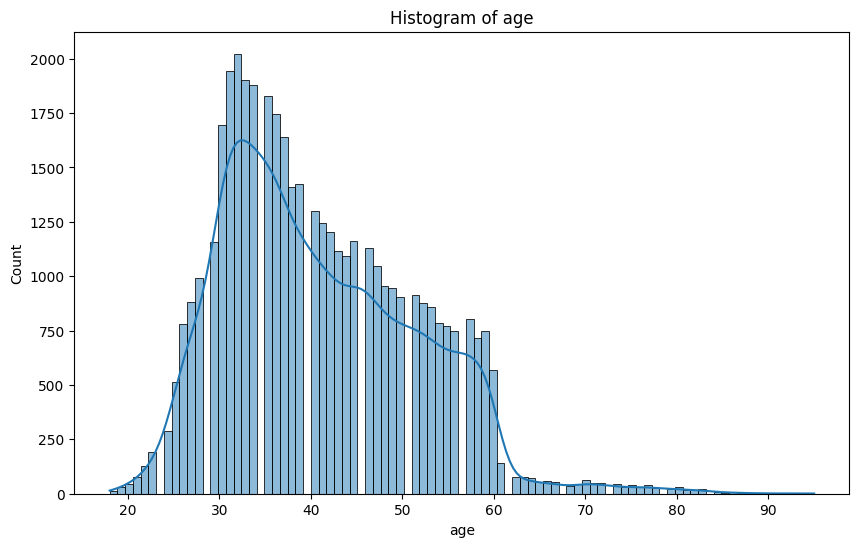

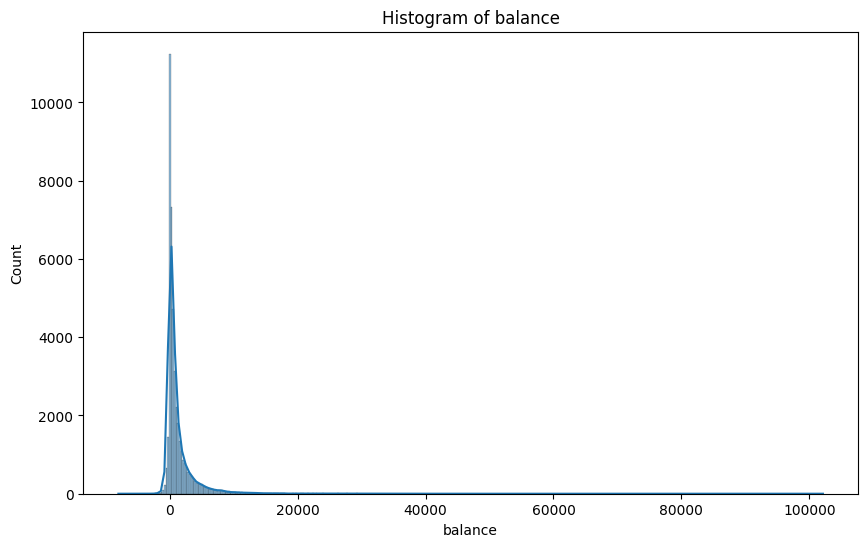

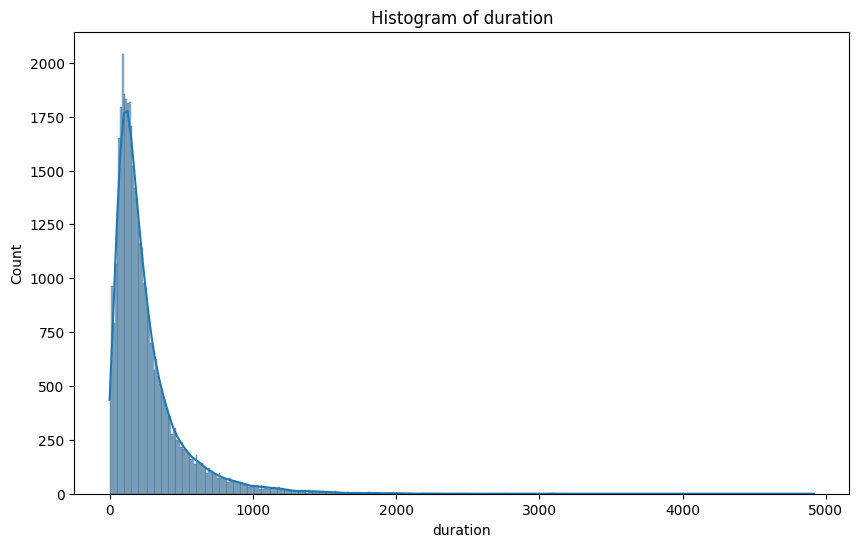

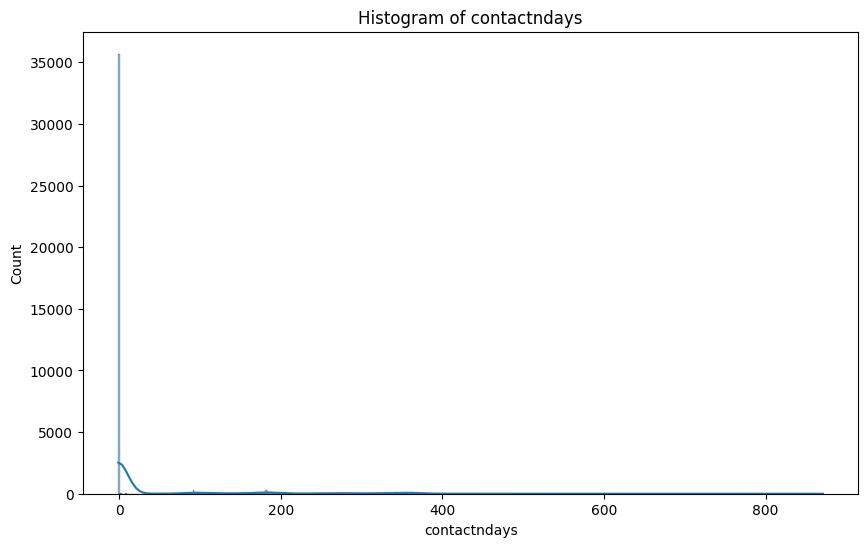

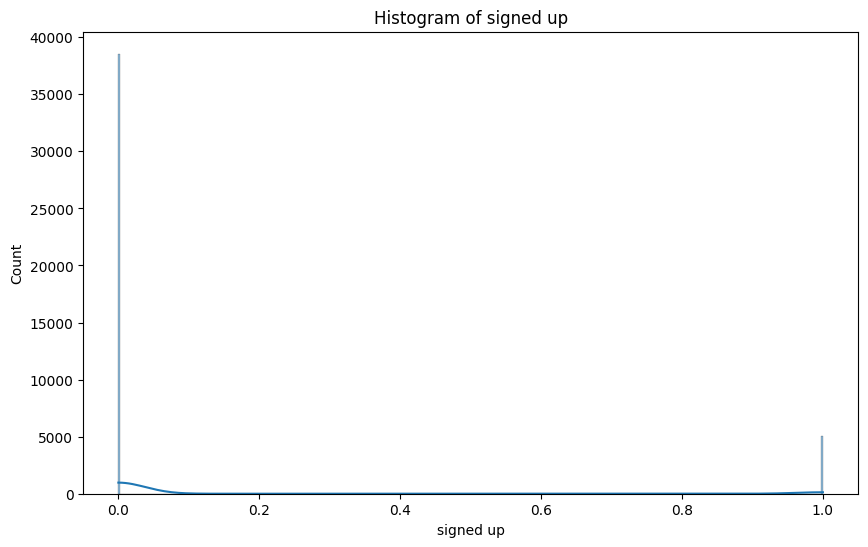

In [7]:
# Explore the variables: histograms for numeric values
numeric_columns = bank.select_dtypes(include=['number']).columns
for col in numeric_columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(bank[col], kde=True)
    plt.title(f'Histogram of {col}')
    plt.show()


/tmp/ipykernel_9680/1025260570.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = bank.select_dtypes(include=['object', 'category']).columns


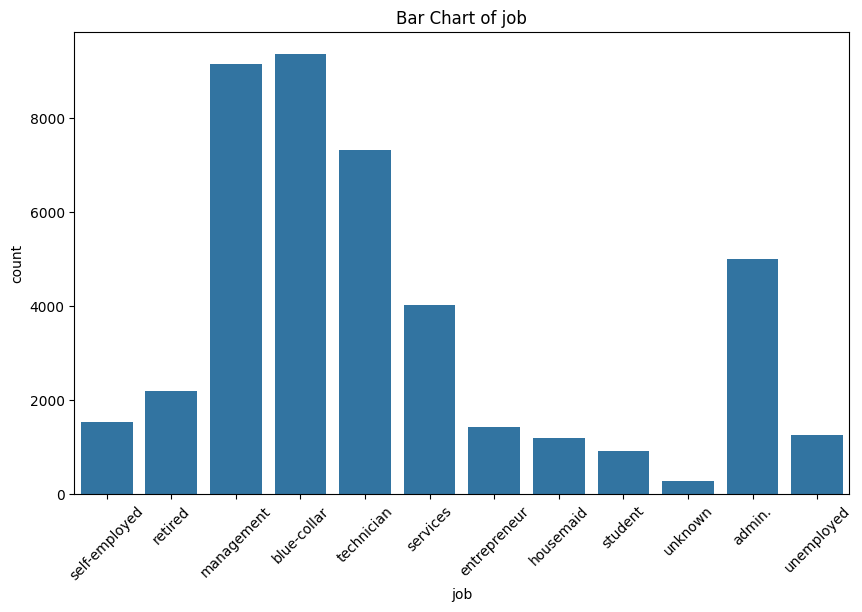

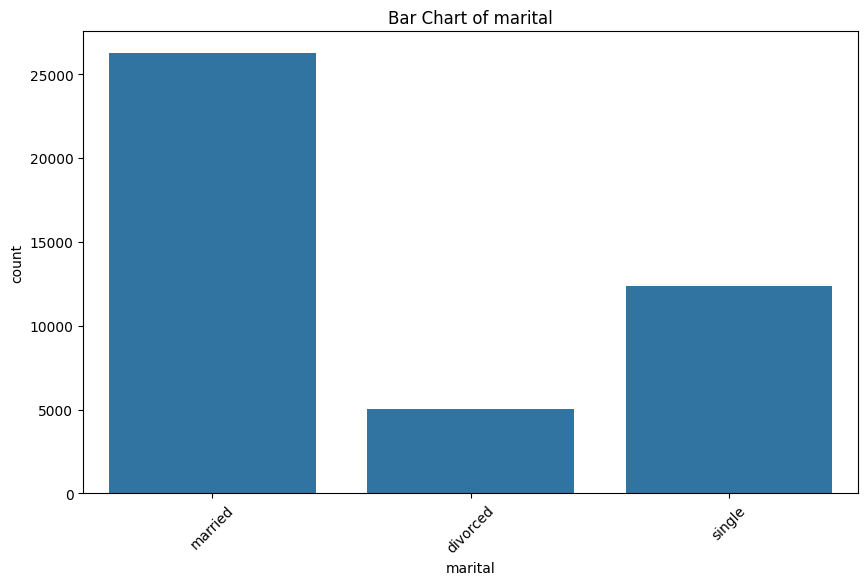

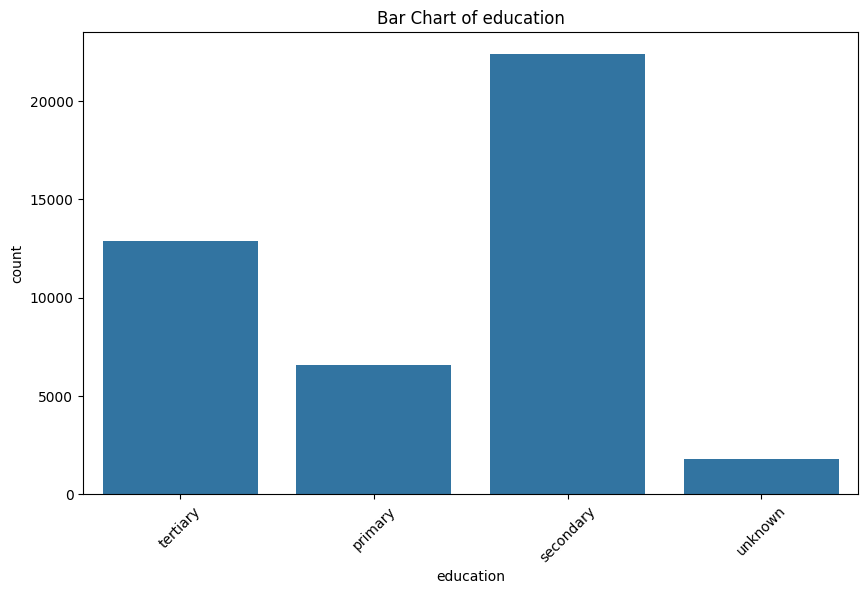

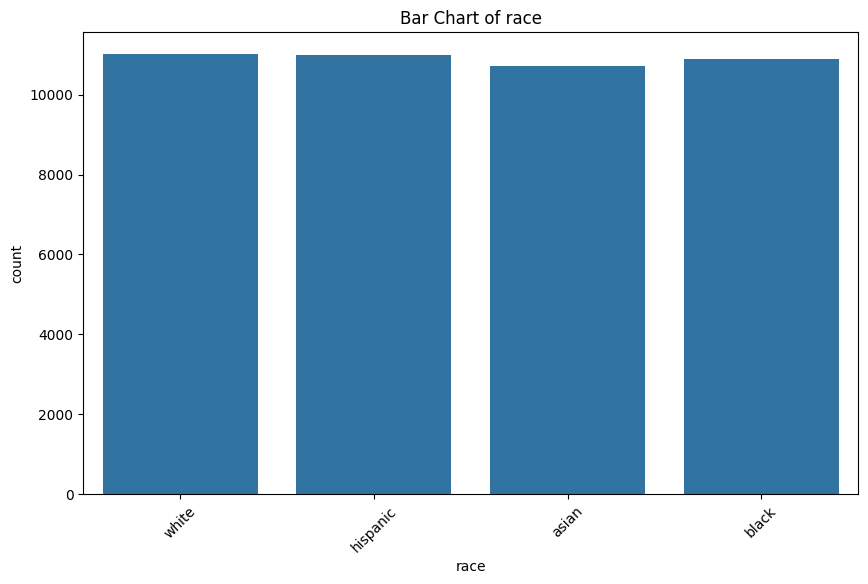

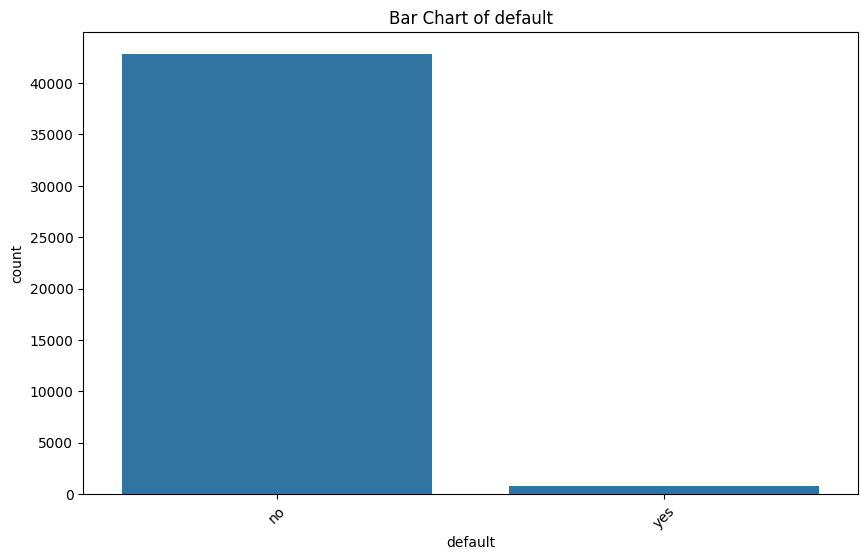

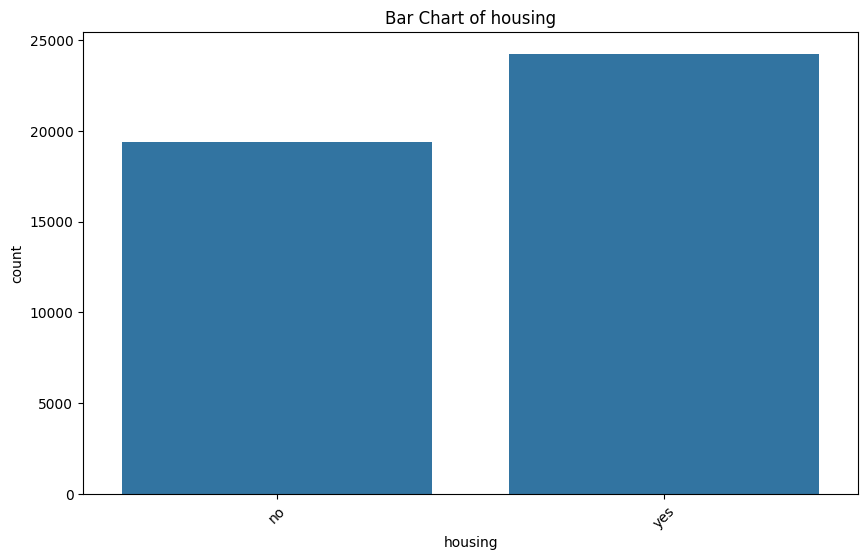

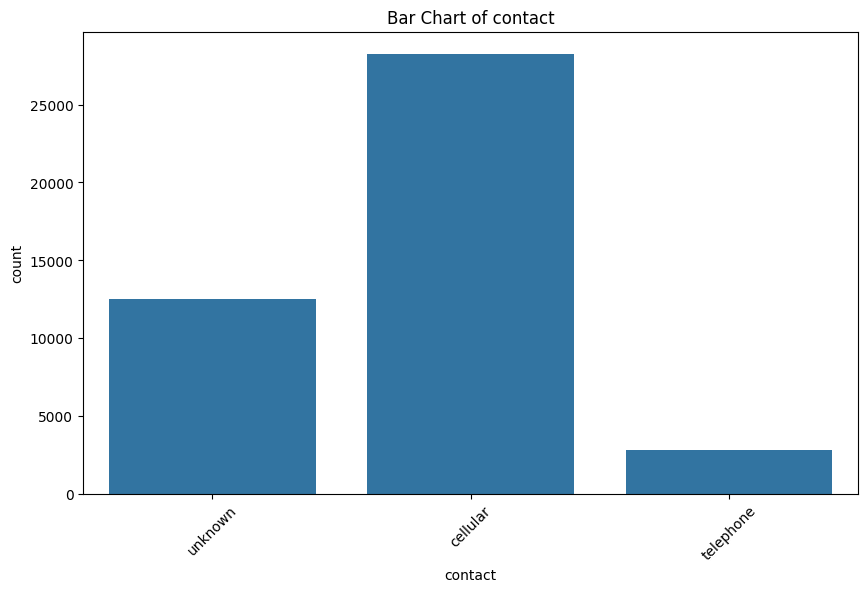

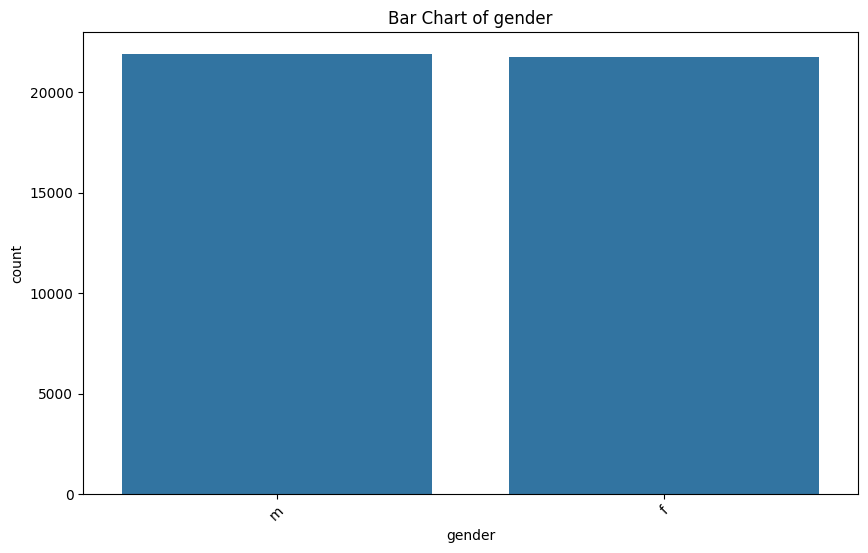

In [8]:
# Bar charts for categorical variables
categorical_columns = bank.select_dtypes(include=['object', 'category']).columns
for col in categorical_columns:
    plt.figure(figsize=(10, 6))
    sns.countplot(x=bank[col])
    plt.title(f'Bar Chart of {col}')
    plt.xticks(rotation=45)
    plt.show()


In [ ]:
# How many numeric columns are in the data set?
num_numeric_columns = bank.select_dtypes(include=['number']).shape[1]
print(f"Number of numeric columns: {num_numeric_columns}")


In [9]:
# Normalization — scale numeric features to 0-1 range using MinMaxScaler
# We exclude 'signed up' (target) from scaling
scaler = MinMaxScaler()
numeric_features = [col for col in bank.select_dtypes(include=['number']).columns if col != 'signed up']
bank[numeric_features] = scaler.fit_transform(bank[numeric_features])


In [10]:
# Convert categorical columns to category dtype
for col in bank.select_dtypes(include=['object']).columns:
    bank[col] = bank[col].astype('category')


/tmp/ipykernel_9680/4016215439.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in bank.select_dtypes(include=['object']).columns:


In [11]:
# Creating dummy variables with drop_first=True to avoid multicollinearity
bank = pd.get_dummies(bank, drop_first=True)

# Check the new shape to see how many columns were added
print("Shape after dummies:", bank.shape)
bank.head()


Shape after dummies: (43628, 29)


,age,balance,duration,contactndays,signed up,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,...,education_tertiary,education_unknown,race_black,race_hispanic,race_white,default_yes,housing_yes,contact_telephone,contact_unknown,gender_m
0,0.324675,0.073384,0.046767,0.000000,0,False,False,False,False,False,...,True,False,False,False,True,False,False,False,True,True
1,0.727273,0.123091,0.051444,0.208716,0,False,False,False,False,True,...,False,False,False,False,True,False,False,False,False,True
2,0.194805,0.076190,0.078081,0.000000,0,False,False,False,True,False,...,True,False,False,True,False,False,False,False,False,True
3,0.246753,0.081283,0.052460,0.000000,0,True,False,False,False,False,...,False,False,False,False,False,False,False,False,True,True
4,0.155844,0.072812,0.014030,0.000000,0,False,False,False,False,False,...,True,False,False,False,True,False,False,False,False,False


In [12]:
# Display missing data using the isnull function
print(bank.isnull().sum())


age                    0
balance                0
duration               0
contactndays           0
signed up              0
job_blue-collar        0
job_entrepreneur       0
job_housemaid          0
job_management         0
job_retired            0
job_self-employed      0
job_services           0
job_student            0
job_technician         0
job_unemployed         0
job_unknown            0
marital_married        0
marital_single         0
education_secondary    0
education_tertiary     0
education_unknown      0
race_black             0
race_hispanic          0
race_white             0
default_yes            0
housing_yes            0
contact_telephone      0
contact_unknown        0
gender_m               0
dtype: int64


In [13]:
# Remove missing values if needed
bank = bank.dropna()
print("Shape after dropping NAs:", bank.shape)


Shape after dropping NAs: (43628, 29)


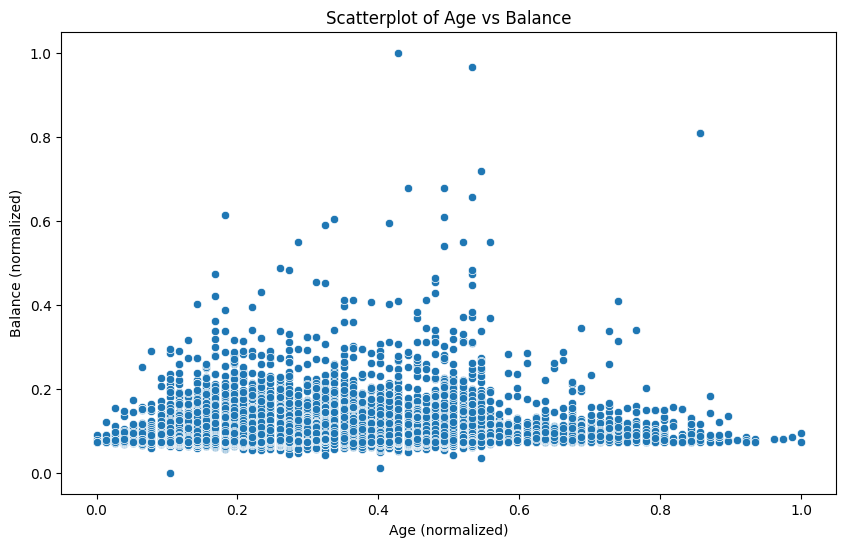

In [14]:
# Scatterplot between two continuous variables
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='balance', data=bank)
plt.title('Scatterplot of Age vs Balance')
plt.xlabel('Age (normalized)')
plt.ylabel('Balance (normalized)')
plt.savefig('scatterplot.png')
plt.show()


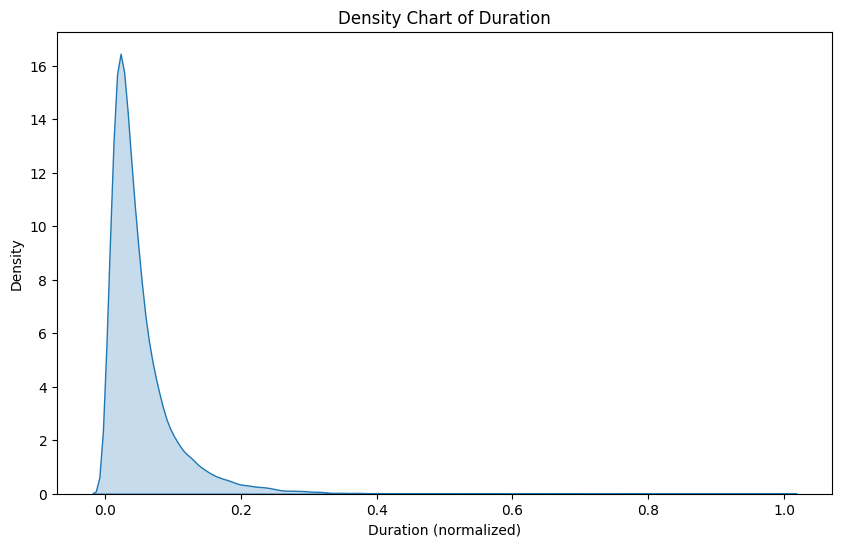

In [15]:
# Density chart of a continuous variable
plt.figure(figsize=(10, 6))
sns.kdeplot(bank['duration'], fill=True)
plt.title('Density Chart of Duration')
plt.xlabel('Duration (normalized)')
plt.show()


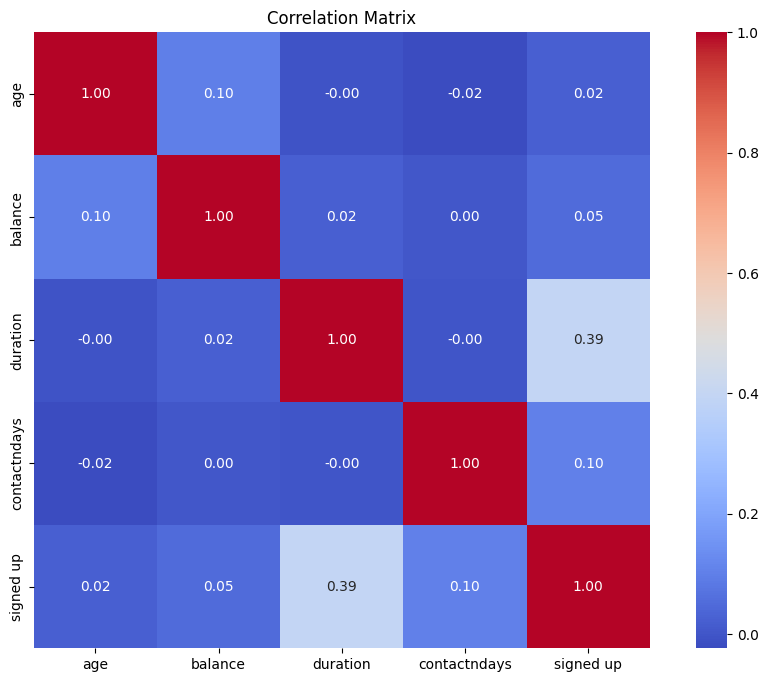

In [16]:
# Correlation matrix — only numeric variables
num_values = bank.select_dtypes(include=['number'])
correlation_matrix = num_values.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Matrix')
plt.show()


## Analytics: Build a model and Tune it for Best Performance


In [17]:
# The 'target' is the variable we are trying to predict: 'signed up'
# Prevalence = proportion of positive class (signed up = 1)
target_prevalence = bank['signed up'].mean()
print(f'Target Prevalence: {target_prevalence:.4f}')
print(f'Count of signed up = 1: {bank["signed up"].sum()}')
print(f'Count of signed up = 0: {(bank["signed up"] == 0).sum()}')


Target Prevalence: 0.1163
Count of signed up = 1: 5074
Count of signed up = 0: 38554


In [18]:
# Divide the dataset into features and target
target = bank['signed up']
features = bank.drop(columns=['signed up'])

print(f"Number of features: {features.shape[1]}")


Number of features: 28


In [19]:
# Train/test split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")


Training set size: 34902
Test set size: 8726


In [20]:
# Test 10 values of k (odd values from 1 to 19) and record accuracies
accuracy_results = {}

for k in range(1, 21, 2):
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_train, y_train)
    accuracy = knn_model.score(X_test, y_test)
    accuracy_results[k] = accuracy
    print(f"k={k}: Accuracy = {accuracy:.4f}")


k=1: Accuracy = 0.8589
k=3: Accuracy = 0.8767
k=5: Accuracy = 0.8796
k=7: Accuracy = 0.8802
k=9: Accuracy = 0.8828
k=11: Accuracy = 0.8823
k=13: Accuracy = 0.8813
k=15: Accuracy = 0.8806
k=17: Accuracy = 0.8807
k=19: Accuracy = 0.8806


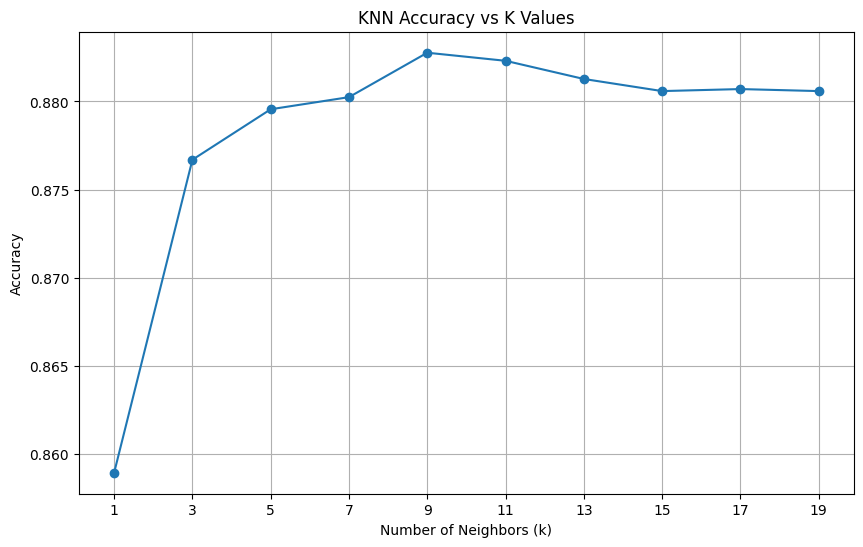

In [21]:
# Graph of accuracy vs k values
plt.figure(figsize=(10, 6))
plt.plot(list(accuracy_results.keys()), list(accuracy_results.values()), marker='o')
plt.title('KNN Accuracy vs K Values')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.xticks(list(accuracy_results.keys()))
plt.grid()
plt.show()


In [22]:
# Using the best k value (k=9 gave the highest accuracy), rerun the model
best_k = 9
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train, y_train)
y_pred = knn_model.predict(X_test)

print(f"Best k: {best_k}")
print(f"Accuracy: {knn_model.score(X_test, y_test):.4f}")


Best k: 9
Accuracy: 0.8828


## Value: Evaluation and Protected Classes


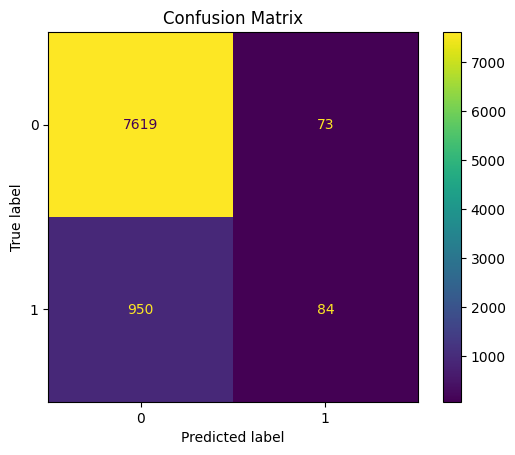

In [23]:
# Confusion matrix for the model's predictions
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Confusion Matrix')
plt.show()


In [24]:
# Compute fairness metrics using Fairlearn

my_metrics = {
    'true positive rate' : true_positive_rate,
    'false positive rate' : false_positive_rate,
    'selection rate' : selection_rate,
    'count' : count
}

# Construct a MetricFrame for race (using race_hispanic as sensitive feature)
mf_race = MetricFrame(
    metrics=my_metrics,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=X_test["race_hispanic"]
)

# Construct a MetricFrame for gender
mf_gender = MetricFrame(
    metrics=my_metrics,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=X_test["gender_m"]
)


In [25]:
# Race fairness by group — run this cell multiple times, changing the 
# sensitive feature to race_black, race_hispanic, race_white to see each breakdown
mf_race.by_group


,true positive rate,false positive rate,selection rate,count
race_hispanic,,,,
False,0.078811,0.008784,0.017021,6580.0
True,0.088462,0.011665,0.020969,2146.0


In [26]:
# Gender fairness by group
mf_gender.by_group


,true positive rate,false positive rate,selection rate,count
gender_m,,,,
False,0.073874,0.010537,0.018616,4351.0
True,0.089770,0.008470,0.017371,4375.0


In [27]:
# Derived fairness metrics for gender (bi-variate)
dpr_gender = fairlearn.metrics.demographic_parity_ratio(y_test, y_pred, sensitive_features=X_test['gender_m'])
print("Demographic Parity ratio:\t", dpr_gender)

eodds_gender = fairlearn.metrics.equalized_odds_ratio(y_test, y_pred, sensitive_features=X_test['gender_m'])
print("Equalized Odds ratio:\t\t", eodds_gender)


Demographic Parity ratio:	 0.9331245149911817
Equalized Odds ratio:		 0.8038244353182752


In [28]:
# Derived fairness metrics for race — uses filter(regex) to pull in all race columns
dpr_race = fairlearn.metrics.demographic_parity_ratio(y_test, y_pred, sensitive_features=X_test.filter(regex="race.*"))
print("Demographic Parity ratio:\t", dpr_race)

eodds_race = fairlearn.metrics.equalized_odds_ratio(y_test, y_pred, sensitive_features=X_test.filter(regex="race.*"))
print("Equalized Odds ratio:\t\t", eodds_race)


Demographic Parity ratio:	 0.7515133323327831
Equalized Odds ratio:		 0.6497772061187927


In [ ]:
# Optional: add, commit, and push changes to your GitHub repository
!git add .
!git commit -m "Completed final project notebook"
!git push
